In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

try:
    from biblioteca_auxiliar.morph import *
    mm.install()
except:
    print("Aviso: Biblioteca morph.py não encontrada localmente.")

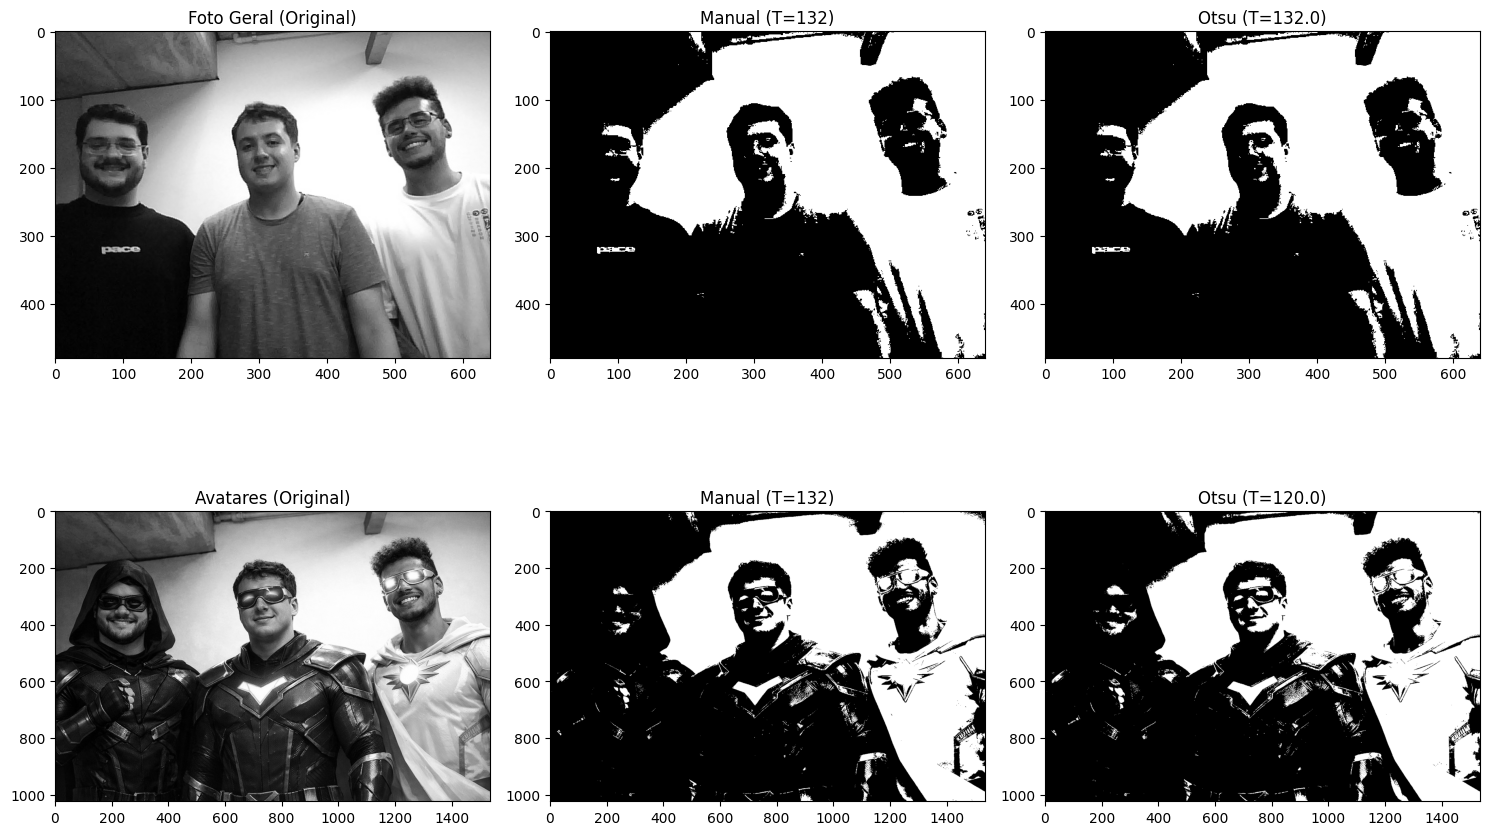

In [6]:
# 3.a)
img_geral = cv2.imread('imagens/foto-geral.jpg', 0)
img_avatar = cv2.imread('imagens/foto_avatar.png', 0)

if img_geral is not None and img_avatar is not None:
    limiar_manual = 132
    
    T_otsu_geral, otsu_geral = cv2.threshold(img_geral, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    T_otsu_avatar, otsu_avatar = cv2.threshold(img_avatar, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    plt.figure(figsize=(15, 10))
    
    plt.subplot(231), plt.imshow(img_geral, "gray"), plt.title('Foto Geral (Original)')
    plt.subplot(234), plt.imshow(img_avatar, "gray"), plt.title('Avatares (Original)')
    
    plt.subplot(232), plt.imshow(img_geral > limiar_manual, "gray"), plt.title(f'Manual (T={limiar_manual})')
    plt.subplot(235), plt.imshow(img_avatar > limiar_manual, "gray"), plt.title(f'Manual (T={limiar_manual})')

    plt.subplot(233), plt.imshow(otsu_geral, "gray"), plt.title(f'Otsu (T={T_otsu_geral})')
    plt.subplot(236), plt.imshow(otsu_avatar, "gray"), plt.title(f'Otsu (T={T_otsu_avatar})')
    
    plt.tight_layout()
    plt.show()
else:
    print("Por favor, insira 'foto-geral.jpg' e 'foto_avatar.png' no diretório.")

In [ ]:
# 3.b)
def LimiarManual(img, limiar=150):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, c = cv2.threshold(gray, limiar, 255, cv2.THRESH_BINARY)
    return cv2.cvtColor(c, cv2.COLOR_GRAY2BGR)

def LimiarAutomatico(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    T, c = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)
    return cv2.cvtColor(c, cv2.COLOR_GRAY2BGR)

cap = cv2.VideoCapture(0)
width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
fps = 30.0

fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter('imagens/saida.avi', fourcc, fps, (int(width)*2, int(height))) 

threshold_type = 'auto'

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break
        
    if threshold_type == 'auto':
        frame_limiar = LimiarAutomatico(frame)
        modo_texto = "Modo: OTSU (Auto)"
    else:
        frame_limiar = LimiarManual(frame)
        modo_texto = "Modo: MANUAL (T=150)"
        
    cv2.putText(frame_limiar, modo_texto, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    concat = cv2.hconcat([frame, frame_limiar])
    cv2.imshow('PDI - Limiarizacao Webcam', concat)
    out.write(concat)
    
    key = cv2.waitKey(1) & 0xFF
    if key == ord('c'):
        threshold_type = 'manual' if threshold_type == 'auto' else 'auto'
    elif key == ord('q'):
        break

cap.release()
out.release()
cv2.destroyAllWindows()

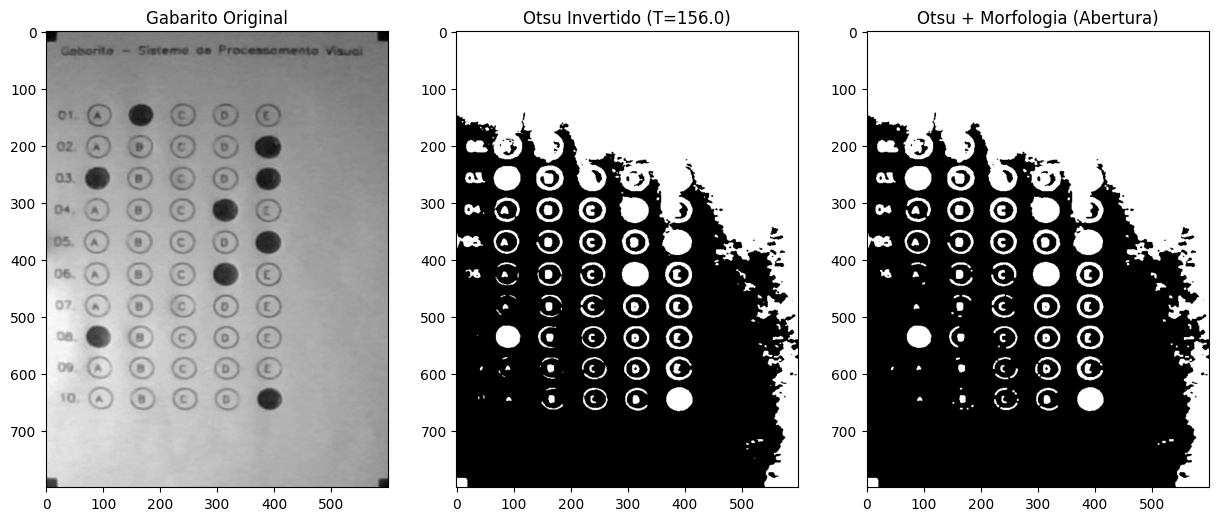

In [14]:
# 4.a)
img_gabarito = cv2.imread('imagens/gabarito_teste.jpg', 0)

if img_gabarito is not None:
    blurred = cv2.GaussianBlur(img_gabarito, (5, 5), 0)

    T_otsu, thresh_gabarito = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    kernel = np.ones((3,3), np.uint8)
    thresh_limpa = cv2.morphologyEx(thresh_gabarito, cv2.MORPH_OPEN, kernel)

    plt.figure(figsize=(15, 6))
    plt.subplot(131), plt.imshow(img_gabarito, "gray"), plt.title('Gabarito Original')
    plt.subplot(132), plt.imshow(thresh_gabarito, "gray"), plt.title(f'Otsu Invertido (T={T_otsu})')
    plt.subplot(133), plt.imshow(thresh_limpa, "gray"), plt.title('Otsu + Morfologia (Abertura)')
    plt.show()
else:
    print("Imagem 'gabarito_teste.png' não encontrada.")